# Liberaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore")

sns.set_style('darkgrid')
sns.set_palette('crest_r')
import re

from sklearn.model_selection import KFold,cross_val_score


from sklearn.pipeline import Pipeline

import  sklearn
from sklearn.model_selection import train_test_split

from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV

#feature engineering
from sklearn.feature_selection import mutual_info_regression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer

# For preprocessing
from sklearn.preprocessing import RobustScaler,StandardScaler,MinMaxScaler,MaxAbsScaler
from sklearn.preprocessing import PowerTransformer, QuantileTransformer,SplineTransformer,FunctionTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.impute import SimpleImputer ,KNNImputer
from sklearn.compose import ColumnTransformer
# For Modeling and Traning
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost.sklearn import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression,SGDRegressor,ElasticNet,Ridge,Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
# For metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error,median_absolute_error,root_mean_squared_error
# For FineTuning
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV


# Data Exploration

In [2]:
df = pd.read_csv('train.csv')
df.head()

,id,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,0,I,1.5250,1.1750,0.3750,28.973189,12.728926,6.647958,8.348928,9
1,1,I,1.1000,0.8250,0.2750,10.418441,4.521745,2.324659,3.401940,8
2,2,M,1.3875,1.1125,0.3750,24.777463,11.339800,5.556502,6.662133,9
3,3,F,1.7000,1.4125,0.5000,50.660556,20.354941,10.991839,14.996885,11
4,4,I,1.2500,1.0125,0.3375,23.289114,11.977664,4.507570,5.953395,8


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74051 entries, 0 to 74050
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              74051 non-null  int64  
 1   Sex             74051 non-null  object 
 2   Length          74051 non-null  float64
 3   Diameter        74051 non-null  float64
 4   Height          74051 non-null  float64
 5   Weight          74051 non-null  float64
 6   Shucked Weight  74051 non-null  float64
 7   Viscera Weight  74051 non-null  float64
 8   Shell Weight    74051 non-null  float64
 9   Age             74051 non-null  int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 5.6+ MB


In [4]:
df.isna().sum()

,0
id,0
Sex,0
Length,0
Diameter,0
Height,0
Weight,0
Shucked Weight,0
Viscera Weight,0
Shell Weight,0
Age,0


In [5]:
df.dropna(inplace=True)

In [6]:
df.drop(columns=['id'],inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df_num = df.select_dtypes(include=[np.number])
df_cat = df.select_dtypes(exclude=[np.number])

In [9]:
df_num.describe()

,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
count,74051.000000,74051.000000,74051.000000,74051.000000,74051.000000,74051.000000,74051.000000,74051.000000
mean,1.317460,1.024496,0.348089,23.385217,10.104270,5.058386,6.723870,9.967806
std,0.287757,0.237396,0.092034,12.648153,5.618025,2.792729,3.584372,3.175189
min,0.187500,0.137500,0.000000,0.056699,0.028349,0.042524,0.042524,1.000000
25%,1.150000,0.887500,0.300000,13.437663,5.712424,2.863300,3.968930,8.000000
50%,1.375000,1.075000,0.362500,23.799405,9.908150,4.989512,6.931453,10.000000
75%,1.537500,1.200000,0.412500,32.162508,14.033003,6.988152,9.071840,11.000000
max,2.012815,1.612500,2.825000,80.101512,42.184056,21.545620,28.491248,29.000000


In [10]:
df_cat.describe()

,Sex
count,74051
unique,3
top,M
freq,27084


In [11]:
df['Sex'].unique()

array(['I', 'M', 'F'], dtype=object)

In [12]:
df2=df.copy()

* there is no null values
* there is no duplicates
* `id ` is a useless column so i dropped it
* `height` column has a min value of zero which is abnormal
* there are outliers and skewness and we will figure it later
* `Shucked weight` + `Viscera weight ` + `Shell weight` are almost equal `Weigth`

# Visualization

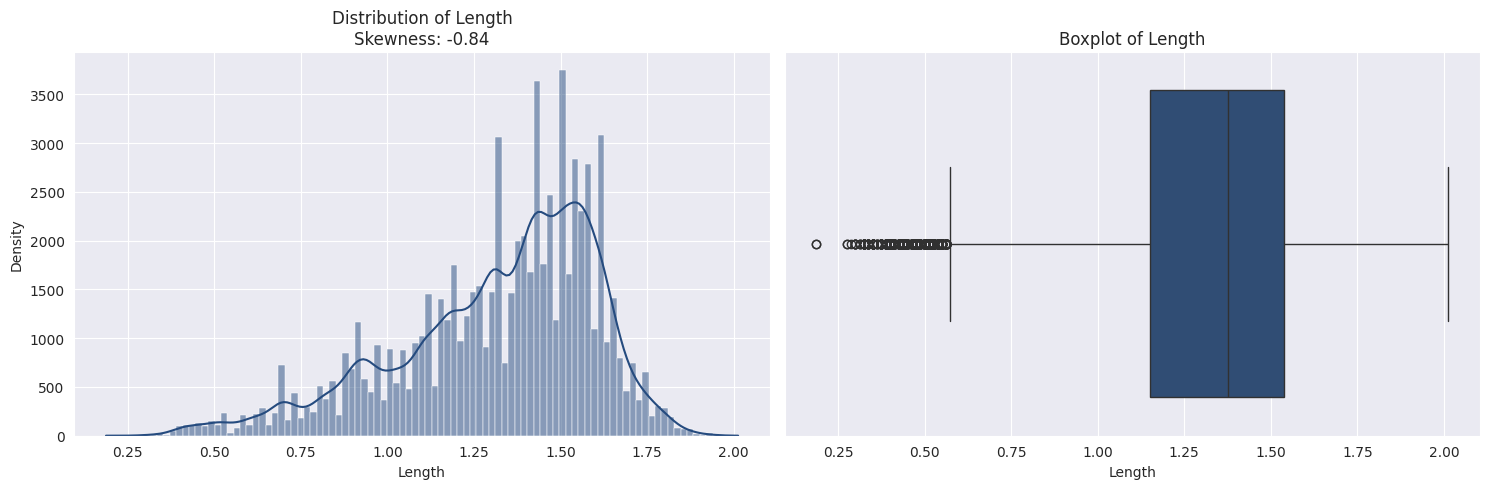

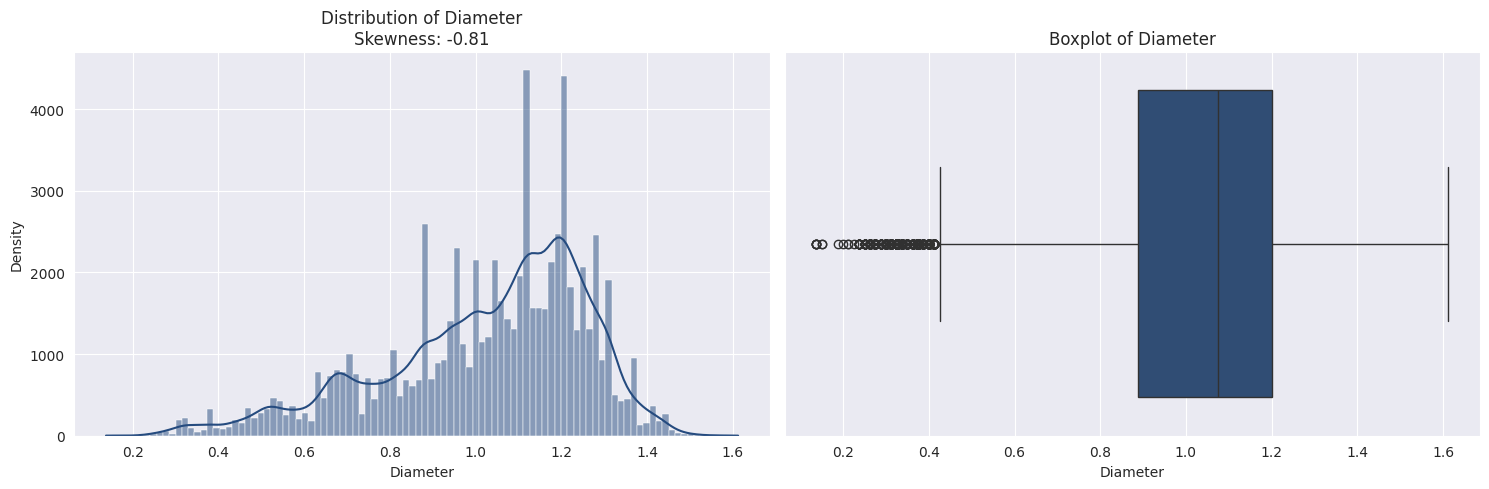

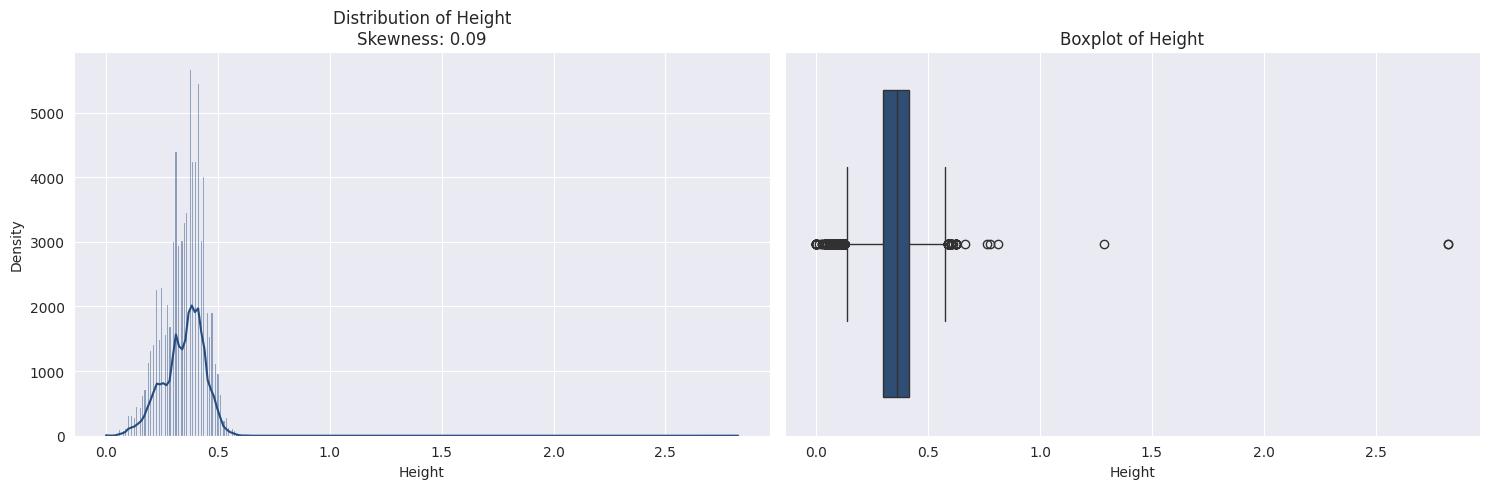

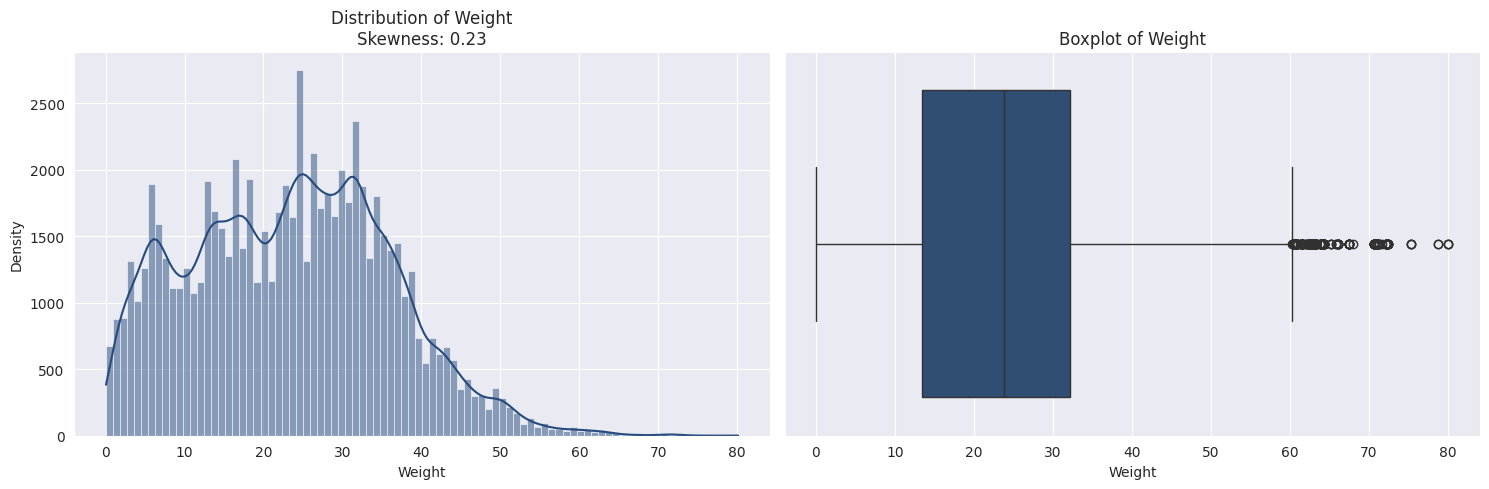

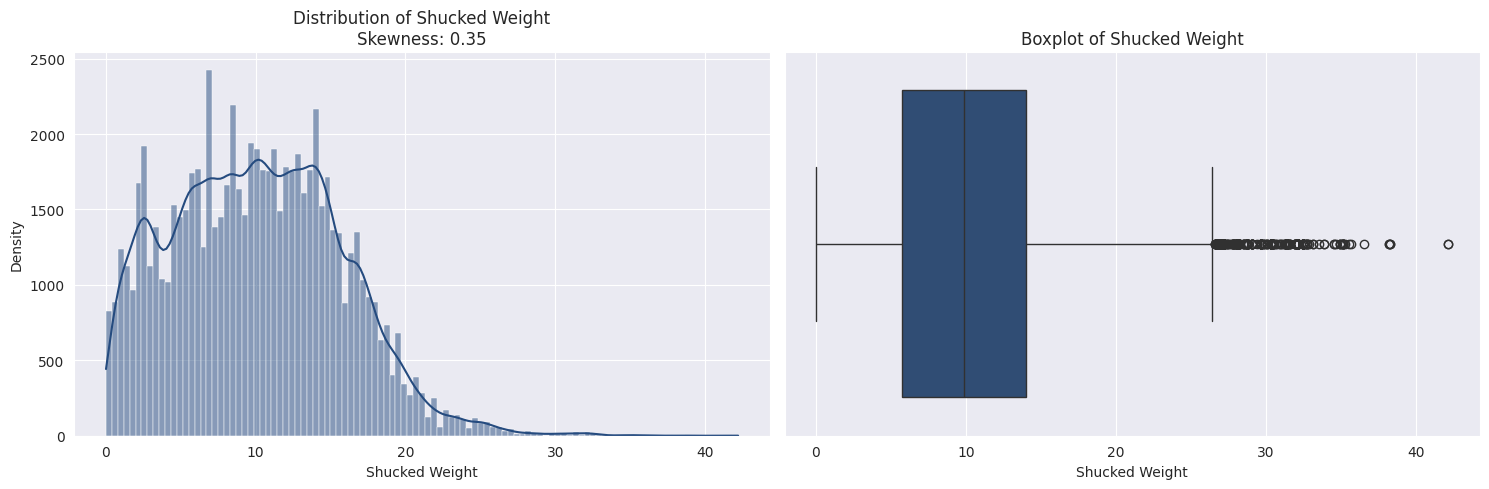

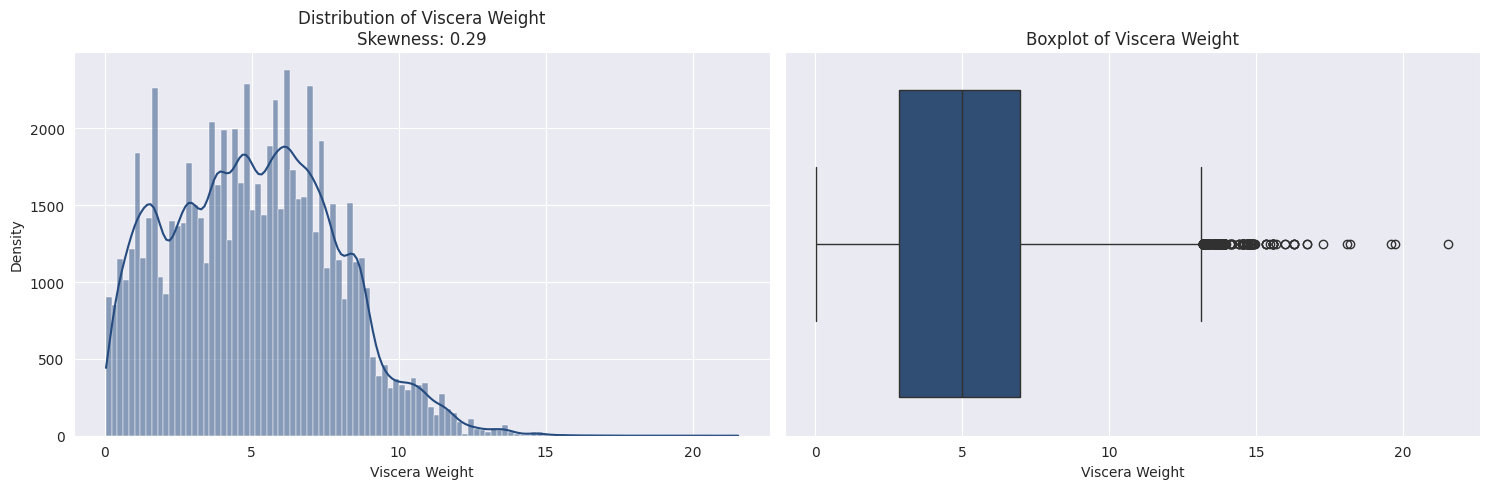

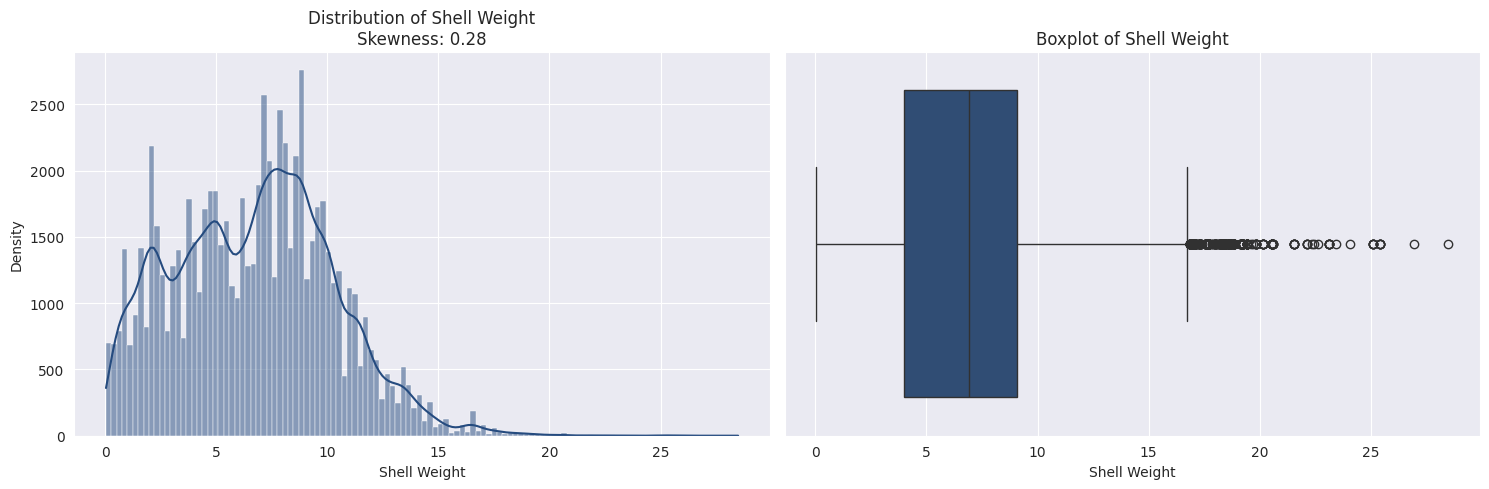

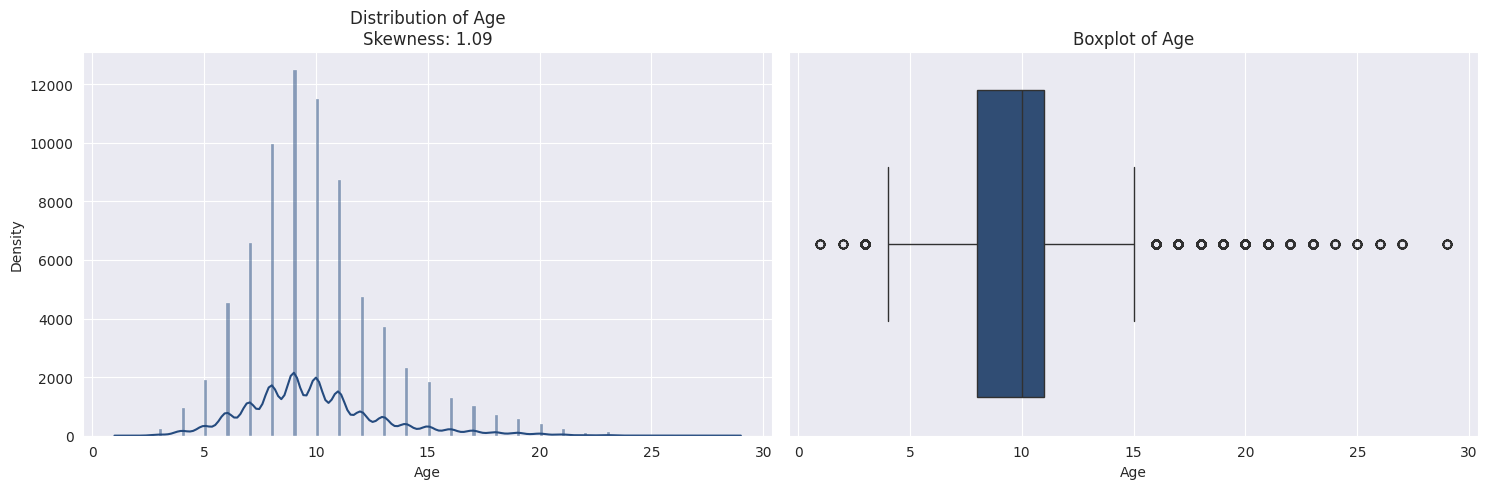

In [13]:

import scipy.stats as stats

def visualize_data(data, column):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Skewness visualization
    skewness = stats.skew(data[column])
    sns.histplot(data[column], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {column}\nSkewness: {skewness:.2f}')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Density')

    # Boxblot visualization
    sns.boxplot(x=data[column], ax=axes[1])
    axes[1].set_title(f'Boxplot of {column}')
    axes[1].set_xlabel(column)

    #automatically adjusts the spacing between subplots to prevent overlapping and make the visualization clear.
    plt.tight_layout()
    plt.show()

for column in df2[df_num.columns]:
    visualize_data(df2, column)


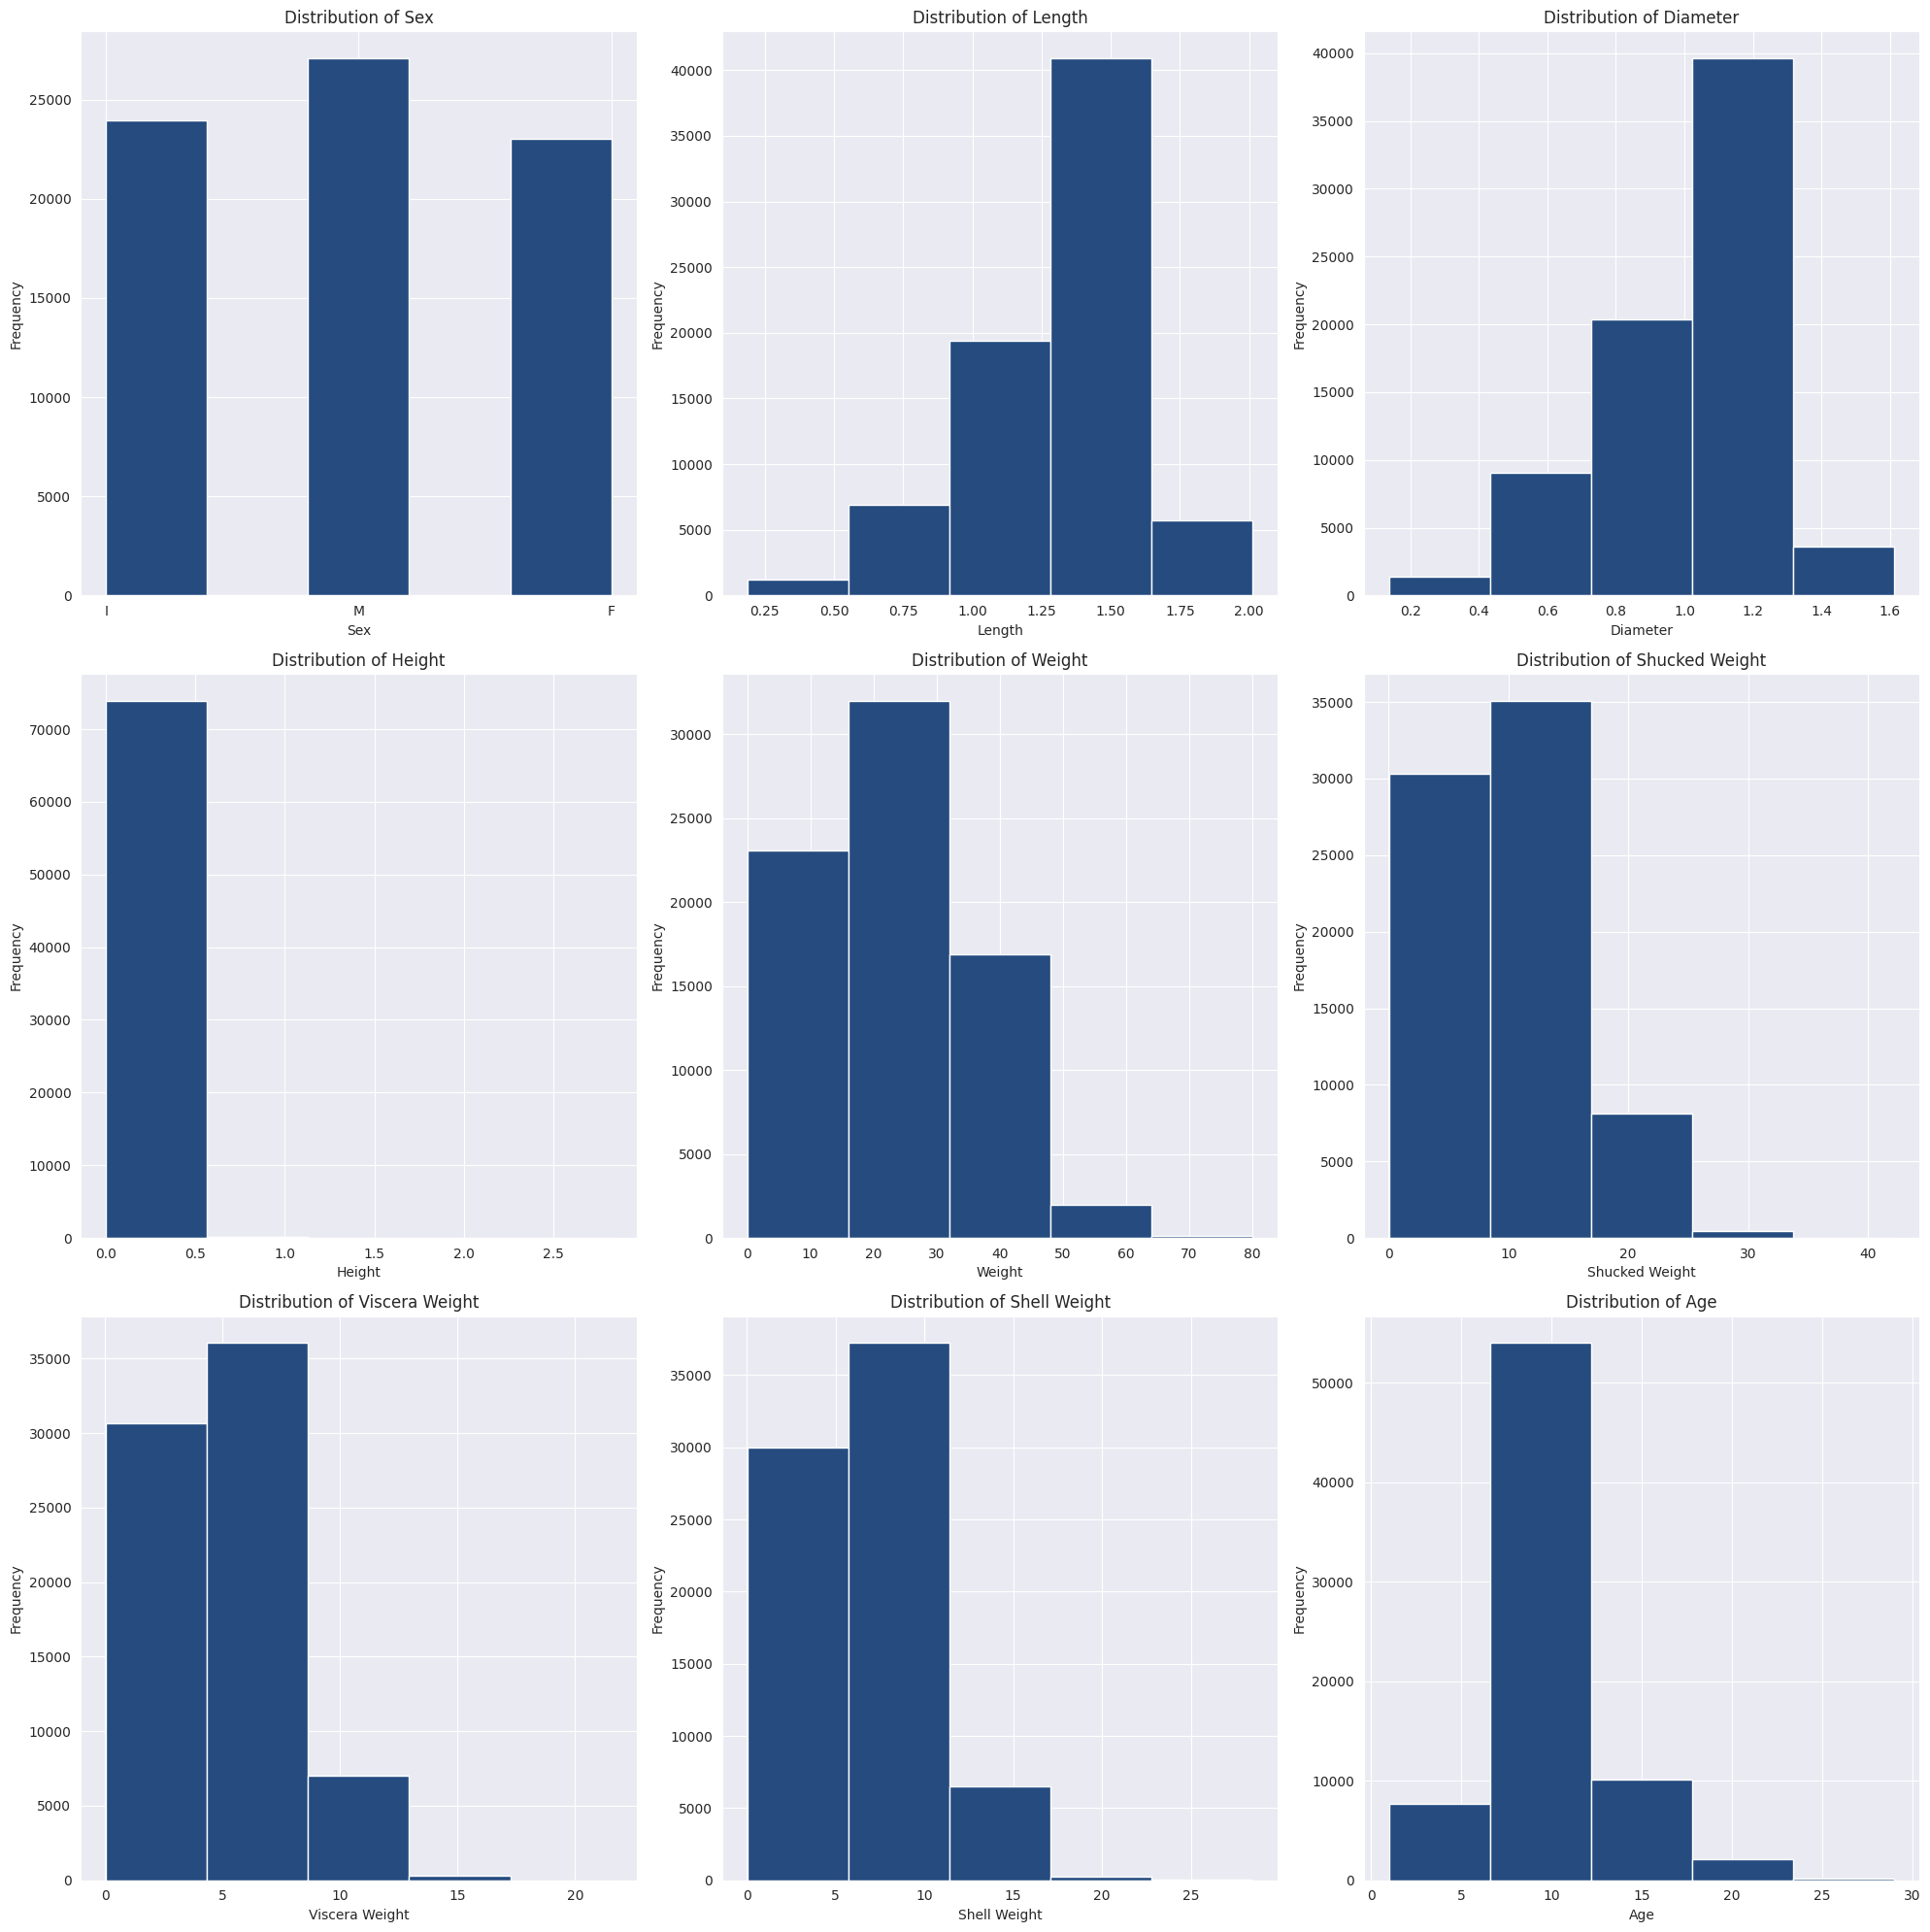

In [14]:
# Set up subplots
num_plots = len(df.columns)
cols_per_row = 3
rows = int(np.ceil(num_plots / cols_per_row))

fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, 20))
axes = axes.flatten()  # Flatten in case of multiple rows

# Plot each histogram
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=5)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


- `Length` , `Diameter` have left skewness and ouliers and multipeaks

- `Height`  has slight right skewness and multipeaks in addition to that it has so bad outliers

- `Weight` and forsure the other *Weights* have right skewness and multipeaks and also outleir

- `Age` has Right Skewness and gaps and multipeaks


In [15]:
df2.select_dtypes(exclude='object').skew()

,0
Length,-0.844377
Diameter,-0.812866
Height,0.086578
Weight,0.231465
Shucked Weight,0.349472
Viscera Weight,0.286383
Shell Weight,0.277459
Age,1.092919


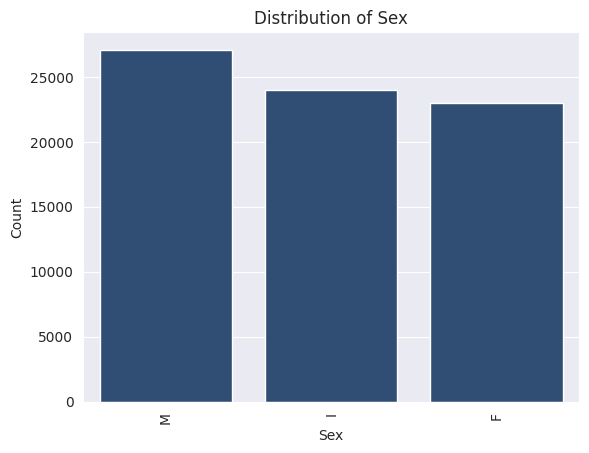

In [16]:
def visualize_categorical_distribution(data, column):
    sns.countplot(data=df2, x=column , order = df2[column].value_counts().index )
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=90)

    plt.show()


for column in df_cat.columns:
    visualize_categorical_distribution(df2, column)

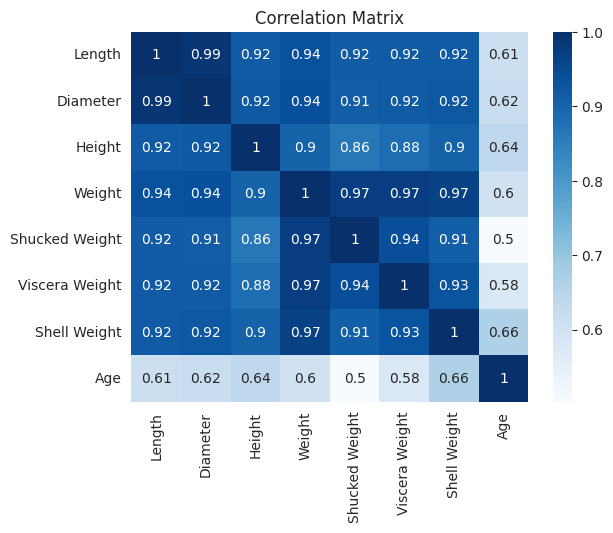

In [17]:
sns.heatmap(df2[df_num.columns].corr(), annot = True,cmap="Blues")
plt.title('Correlation Matrix')
plt.show()

In [18]:
df[['Length','Diameter','Height','Weight']].isin([0]).sum()


,0
Length,0
Diameter,0
Height,24
Weight,0


In [19]:
# Remove zero or negative values in physical features
features = ['Length', 'Diameter', 'Height', 'Weight', 'Shucked Weight', 'Viscera Weight', 'Shell Weight']
df = df[(df[features] > 0).all(axis=1)]

# Remove outliers using IQR method
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

df.reset_index(drop=True, inplace=True)


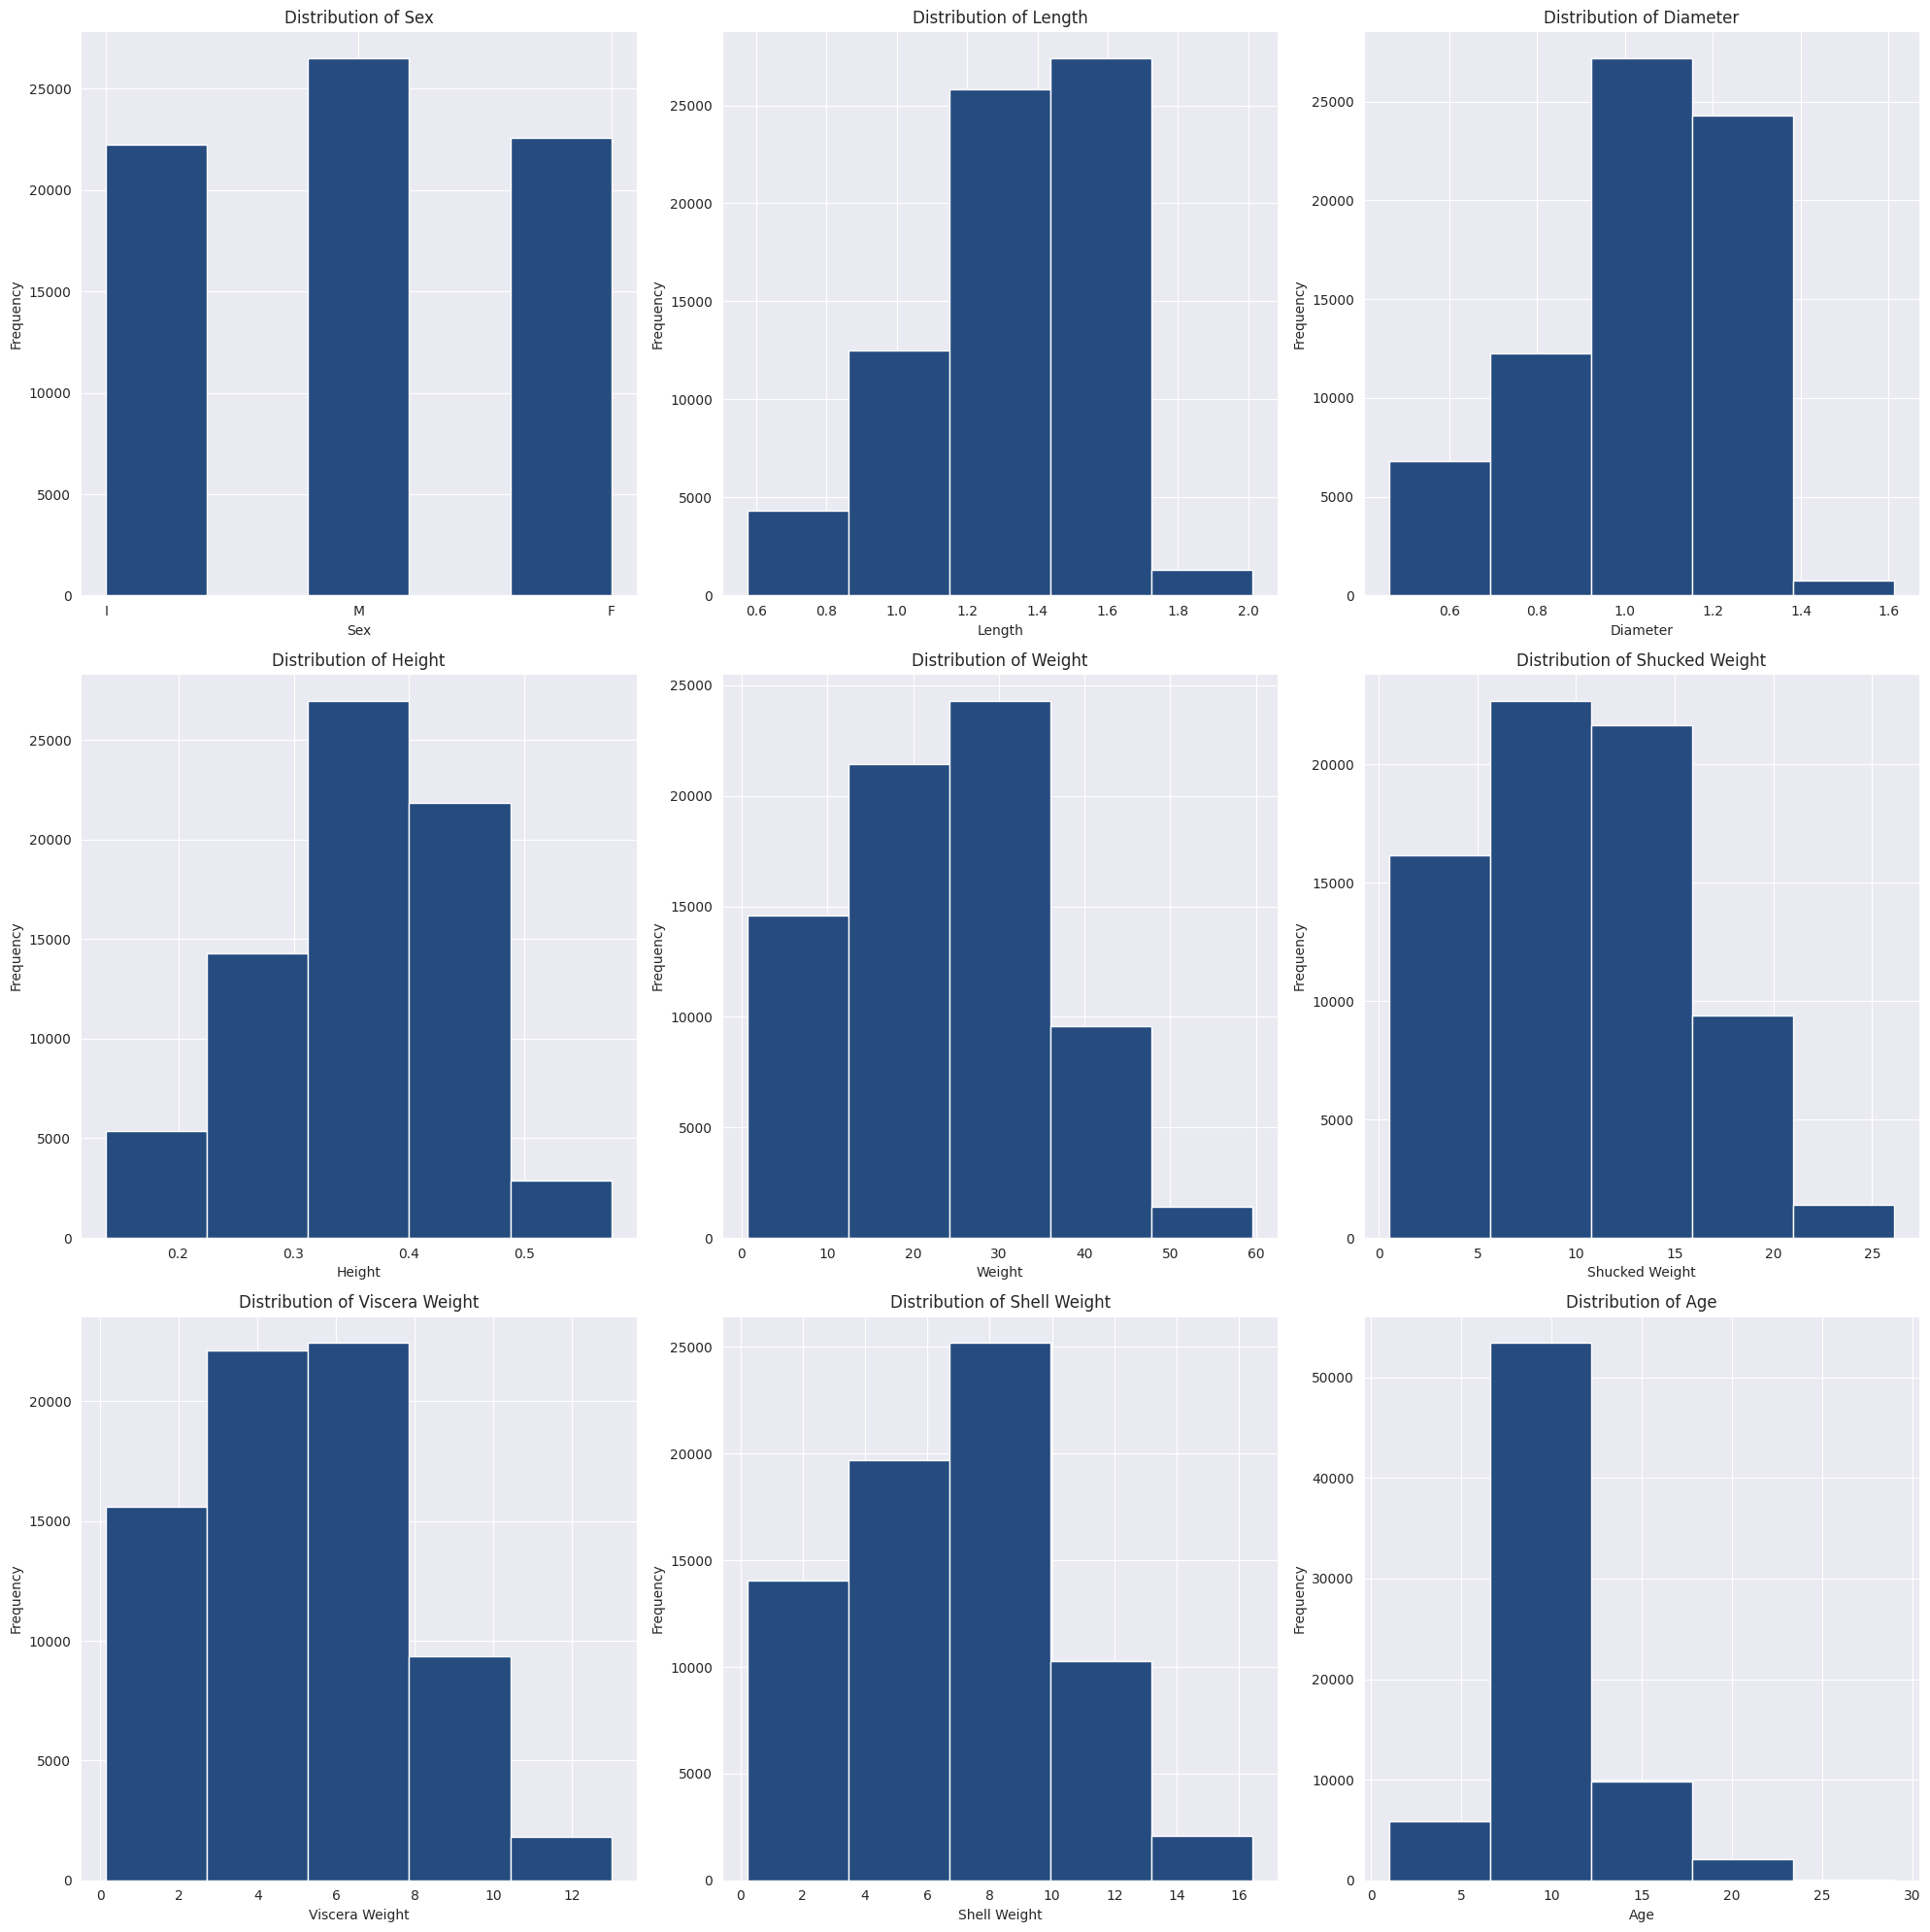

In [20]:
# Set up subplots
num_plots = len(df.columns)
cols_per_row = 3
rows = int(np.ceil(num_plots / cols_per_row))

fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, 20))
axes = axes.flatten()  # Flatten in case of multiple rows

# Plot each histogram
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=5)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [21]:
y= df2['Age']

mutual_df_num = df2[df_num.columns]

mutual_info = mutual_info_regression(mutual_df_num, y, random_state=1)

mutual_info = pd.Series(mutual_info)
mutual_info.index = mutual_df_num.columns
pd.DataFrame(mutual_info.sort_values(ascending=False), columns = ["MI_score"] )

,MI_score
Age,2.481381
Shell Weight,0.563782
Weight,0.509694
Viscera Weight,0.490948
Height,0.488982
Diameter,0.487151
Length,0.477633
Shucked Weight,0.455130


In [22]:
mutual_df_cat = df2[df_cat.columns]

for col in mutual_df_cat:
    mutual_df_cat[col], _  = mutual_df_cat[col].factorize()

mutual_info = mutual_info_regression(mutual_df_cat, y, random_state=1)

mutual_info = pd.Series(mutual_info)
mutual_info.index = mutual_df_cat.columns
pd.DataFrame(mutual_info.sort_values(ascending=False), columns = ["MI_score"] )

,MI_score
Sex,0.245434


- `Shell Weight` then `height` then `Diameter` has more correlation with `Age`
- `Shuched Weight` has the least correlation with `Age`
- `Weight` has the same percentage of correlation with other types of *weights* as it has been noticed from earlier
- `Height` has srong correlation with the other
- `Diameter` and `length` has the strongest correlation so we can drop one of them and it is the `length`

In [23]:
X = df.drop('Age', axis=1)
y = df['Age']

In [24]:
x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
numerical_cols = X.select_dtypes(include=np.number).columns
categorical_cols = X.select_dtypes(exclude=np.number).columns

In [26]:
class CustomFeatureEngineering(BaseEstimator, TransformerMixin):
    def __init__(self, add_attributes=True):
        self.add_attributes = add_attributes

    def fit(self, X, y=None):
        return self

    def transform(self, X):
      X_copy = X.copy()

      # First, impute missing depth values before dropping it
    #   X_copy['depth'].fillna(X_copy['depth'].mean(), inplace=True)  # Ensure no NaNs

      # Now, create new features
      X_copy['Volume'] = X_copy['Length'] * X_copy['Weight'] * X_copy['Height']
      X_copy['Shell_weight_ratio'] = X_copy['Shell Weight']/ X_copy['Weight']



      # Drop unnecessary columns *AFTER* fixing NaNs
      X_copy.drop(["Length", "Weight", "Shucked Weight", "Viscera Weight","Diameter"], axis=1, inplace=True)

      return X_copy


## **Data Preparation**


In [27]:
feature_enginnering_pipeline = Pipeline([
    ('custom_feature_engineering', CustomFeatureEngineering())
])

In [28]:
num_pipeline_1=Pipeline([("scaling", StandardScaler()),
                         ("imputer" , SimpleImputer(strategy="median")),
                         ("power", PowerTransformer())])

In [29]:
num_pipeline_2 = Pipeline([("imputer", SimpleImputer(strategy="median")),
                           ("scaling", RobustScaler()),
                           ("power", PowerTransformer())])

In [30]:
num_pipeline_3 = Pipeline([("imputer", KNNImputer(n_neighbors=6)),
                           ("scaling", MinMaxScaler()),
                           ("power", PowerTransformer())])

In [31]:
cat_pipeline = Pipeline([("encoder", OneHotEncoder()),
                         ("imputer",SimpleImputer(strategy="most_frequent"))])

In [32]:
full_pipeline_1 = ColumnTransformer([("feature_engineering", feature_enginnering_pipeline,  ["Length", "Weight", "Shucked Weight", "Viscera Weight","Diameter",'Shell Weight',"Height"]),
                                     ("num",num_pipeline_1,numerical_cols),
                                     ("cat",cat_pipeline,categorical_cols)])

In [33]:
full_pipeline_2 = ColumnTransformer([("feature_engineering", feature_enginnering_pipeline, ["Length", "Weight", "Shucked Weight", "Viscera Weight","Diameter",'Shell Weight',"Height"]),
                                     ("num",num_pipeline_2,numerical_cols),
                                     ("cat",cat_pipeline,categorical_cols)])

In [34]:
full_pipeline_3 = ColumnTransformer([("feature_engineering", feature_enginnering_pipeline, ["Length", "Weight", "Shucked Weight", "Viscera Weight","Diameter",'Shell Weight',"Height"]),
                                     ("num",num_pipeline_3,numerical_cols),
                                     ("cat",cat_pipeline,categorical_cols)])

## **Modeling**

In [35]:
# Define your pipelines
pipelines = [
    ("full_pipeline_1", full_pipeline_1),
    ("full_pipeline_2", full_pipeline_2),
    ("full_pipeline_3", full_pipeline_3)
]

# Define models
models = [
    LinearRegression(),
    DecisionTreeRegressor(random_state=42),
    RandomForestRegressor(n_estimators=100, random_state=42),
    GradientBoostingRegressor(n_estimators=100, random_state=42),
    XGBRegressor(n_estimators=100, random_state=42),
    LGBMRegressor(n_estimators=100, random_state=42)
]

# Store results
results = []

for pipeline_name, pipeline in pipelines:
    for model in models:
        model_pipeline = Pipeline([
            ('preprocessing', pipeline),  # safer name than pipeline_name
            ('regressor', model)          # avoid using 'model' as step name
        ])

        model_pipeline.fit(x_train, y_train)
        y_pred = model_pipeline.predict(x_val)
        y_train_pred = model_pipeline.predict(x_train)

        val_rmse = root_mean_squared_error(y_val, y_pred)
        train_rmse = root_mean_squared_error(y_train, y_train_pred)

        results.append({
            'Model': model.__class__.__name__,
            'Pipeline': pipeline_name,
            'Train_RMSE': train_rmse,
            'Validation_RMSE': val_rmse
        })

# Create and sort results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Validation_RMSE')
results_df.head(6)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005281 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2048
[LightGBM] [Info] Number of data points in the train set: 57050, number of used features: 14
[LightGBM] [Info] Start training from score 10.067239
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005780 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2048
[LightGBM] [Info] Number of data points in the train set: 57050, number of used features: 14
[LightGBM] [Info] Start training from score 10.067239
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005312 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2048
[LightGBM] [Info] Number of data points in the train set: 57050, number of used features: 14
[LightGBM] [Info] Start t

,Model,Pipeline,Train_RMSE,Validation_RMSE
5,LGBMRegressor,full_pipeline_1,1.947079,2.058446
11,LGBMRegressor,full_pipeline_2,1.947079,2.058446
17,LGBMRegressor,full_pipeline_3,1.948790,2.060188
9,GradientBoostingRegressor,full_pipeline_2,2.047732,2.085525
15,GradientBoostingRegressor,full_pipeline_3,2.047732,2.085525
3,GradientBoostingRegressor,full_pipeline_1,2.047732,2.085525


In [36]:
LGBM_Pipeline = Pipeline([
    ("Full Pipeline 1", full_pipeline_1),  # Transformer(s)
    ("Model", LGBMRegressor(n_estimators=100,
                            random_state=42,
                            learning_rate=0.1))
])


In [37]:
LGBM_Pipeline.fit(x_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001933 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2048
[LightGBM] [Info] Number of data points in the train set: 57050, number of used features: 14
[LightGBM] [Info] Start training from score 10.067239


Pipeline(steps=[('Full Pipeline 1',
                 ColumnTransformer(transformers=[('feature_engineering',
                                                  Pipeline(steps=[('custom_feature_engineering',
                                                                   CustomFeatureEngineering())]),
                                                  ['Length', 'Weight',
                                                   'Shucked Weight',
                                                   'Viscera Weight', 'Diameter',
                                                   'Shell Weight', 'Height']),
                                                 ('num',
                                                  Pipeline(steps=[('scaling',
                                                                   StandardScaler()),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('power',
                                                                   PowerTransformer())]),
                                                  Index(['Length', 'Diameter', 'Height', 'Weight', 'Shucked Weight',
       'Viscera Weight', 'Shell Weight'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder()),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  Index(['Sex'], dtype='object'))])),
                ('Model', LGBMRegressor(random_state=42))])

In [38]:
df_test = pd.read_csv('test.csv')
df_test.head()

,id,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight
0,74051,I,1.0500,0.7625,0.2750,8.618248,3.657085,1.729319,2.721552
1,74052,I,1.1625,0.8875,0.2750,15.507176,7.030676,3.246018,3.968930
2,74053,F,1.2875,0.9875,0.3250,14.571643,5.556502,3.883882,4.819415
3,74054,F,1.5500,0.9875,0.3875,28.377849,13.380964,6.548735,7.030676
4,74055,I,1.1125,0.8500,0.2625,11.765042,5.528153,2.466407,3.331066


In [39]:
df_sub = pd.read_csv('sample_submission.csv')
df_sub.head()

,id,Age
0,74051,10
1,74052,10
2,74053,10
3,74054,10
4,74055,10


In [40]:
x_test = df_test.drop('id', axis=1)
y_test = df_sub['Age']



In [41]:
# Evaluate the model on the training, validation, and test sets
train_rmse = root_mean_squared_error(y_train , LGBM_Pipeline.predict(x_train))
val_rmse = root_mean_squared_error(y_val , LGBM_Pipeline.predict(x_val))
test_rmse = root_mean_squared_error(y_test , LGBM_Pipeline.predict(x_test))

print(f"Train RMSE: {train_rmse}")
print(f"Validation RMSE: {val_rmse}")
print(f"Test RMSE: {test_rmse}")

Train RMSE: 1.9470786331450327
Validation RMSE: 2.058446056939927
Test RMSE: 2.40455363195953


## **FineTune**

In [43]:
# ✅ 1. Define the parameter grid for tuning
param_grid = {
    "Model__n_estimators": [50, 100, 150],
    "Model__max_depth": [5, 10, 15, 30],
    "Model__learning_rate": [0.01, 0.1, 0.2, 0.5]
}

# ✅ 2. Grid search setup
grid_search = GridSearchCV(
    LGBM_Pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

# ✅ 3. Fit the model on training data
# fit_params = {"Model__early_stopping_rounds": 50, "Model__eval_set": [(x_val, y_val)], "Model__verbose": False}
grid_search.fit(x_train, y_train)



# ✅ 4. Retrieve best model and results
best_model = grid_search.best_estimator_

train_rmse = np.sqrt(mean_squared_error(y_train, best_model.predict(x_train)))
val_rmse = np.sqrt(mean_squared_error(y_val, best_model.predict(x_val)))
test_rmse = np.sqrt(mean_squared_error(y_test, best_model.predict(x_test)))

print("✅ Best Parameters:", grid_search.best_params_)
print("🏋️‍♂️ Train RMSE:", train_rmse)
print("📊 Validation RMSE:", val_rmse)
print("🧪 Test RMSE:", test_rmse)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009753 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2048
[LightGBM] [Info] Number of data points in the train set: 57050, number of used features: 14
[LightGBM] [Info] Start training from score 10.067239
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 